## 1. Load Processed Dataset

In [28]:
import pandas as pd

df = pd.read_csv(
    "../Data/Processed/risk_scored_dataset_augmented.csv"
)

df.head()

,Financial_Loss,Operational_Disruption,Reputation_Damage_Score,Incident_Response_Time,Recovery_Time,Cybersecurity_Budget,Employee_Training,Use_of_MFA,Data_Backup_Availability,Technical_Score,Human_Score,Org_Score,Impact_Score,Risk_Score,Risk_Level
0,0.008056,0.761208,0.666667,0.392150,0.432813,0.105304,0,0,0,0.0,0,0.105304,0.371293,0.726804,High
1,0.758048,0.597195,0.750000,0.838926,0.338468,0.078036,0,0,0,0.0,0,0.078036,0.690398,0.950732,High
2,0.665349,0.288264,0.666667,0.242147,0.518697,0.193583,0,0,0,0.0,0,0.193583,0.533210,0.819468,High
3,0.715633,0.561428,0.333333,0.798344,0.245326,0.705562,0,0,0,0.0,0,0.705562,0.569572,0.739258,High
4,0.425708,0.562274,0.583333,0.656293,0.300294,0.263583,0,0,0,0.0,0,0.263583,0.495063,0.778999,High


## 2. Dataset Overview

In [29]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

Rows: 8000
Columns: 15
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Financial_Loss            8000 non-null   float64
 1   Operational_Disruption    8000 non-null   float64
 2   Reputation_Damage_Score   8000 non-null   float64
 3   Incident_Response_Time    8000 non-null   float64
 4   Recovery_Time             8000 non-null   float64
 5   Cybersecurity_Budget      8000 non-null   float64
 6   Employee_Training         8000 non-null   int64  
 7   Use_of_MFA                8000 non-null   int64  
 8   Data_Backup_Availability  8000 non-null   int64  
 9   Technical_Score           8000 non-null   float64
 10  Human_Score               8000 non-null   int64  
 11  Org_Score                 8000 non-null   float64
 12  Impact_Score              8000 non-null   float64
 13  Risk_Score                8000 non-null 

## 3. Feature Selection

In [30]:
X = df[
    [
        "Financial_Loss",
        "Operational_Disruption",
        "Reputation_Damage_Score",
        "Incident_Response_Time",
        "Recovery_Time",
        "Cybersecurity_Budget",
        "Employee_Training",
        "Use_of_MFA",
        "Data_Backup_Availability",
        "Technical_Score",
        "Human_Score",
        "Org_Score"
    ]
]

y = df["Risk_Level"]

print(X.shape)
print(y.shape)
print(X.columns.tolist())

(8000, 12)
(8000,)
['Financial_Loss', 'Operational_Disruption', 'Reputation_Damage_Score', 'Incident_Response_Time', 'Recovery_Time', 'Cybersecurity_Budget', 'Employee_Training', 'Use_of_MFA', 'Data_Backup_Availability', 'Technical_Score', 'Human_Score', 'Org_Score']


## 4. Data Splitting

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)


(6400, 12)
(1600, 12)


## 5. Model Evaluation Function

In [32]:
from sklearn.metrics import (
    accuracy_score,
    classification_report
)

def evaluate_model(
    model,
    X_train,
    X_test,
    y_train,
    y_test
):

    model.fit(
        X_train,
        y_train
    )

    predictions = model.predict(
        X_test
    )

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    print(
        f"\nModel: {model.__class__.__name__}"
    )

    print(
        f"Accuracy: {accuracy:.4f}"
    )

    print(
        classification_report(
            y_test,
            predictions
        )
    )

    return accuracy

## 6. Decision Tree Model


Model: DecisionTreeClassifier
Accuracy: 0.7644
              precision    recall  f1-score   support

        High       0.86      0.81      0.84       544
         Low       0.85      0.75      0.80       528
      Medium       0.62      0.73      0.67       528

    accuracy                           0.76      1600
   macro avg       0.78      0.76      0.77      1600
weighted avg       0.78      0.76      0.77      1600



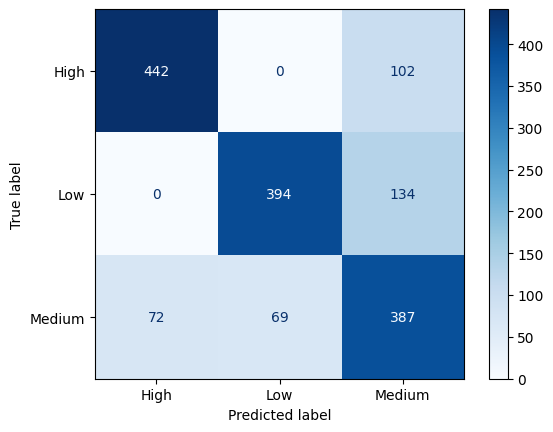

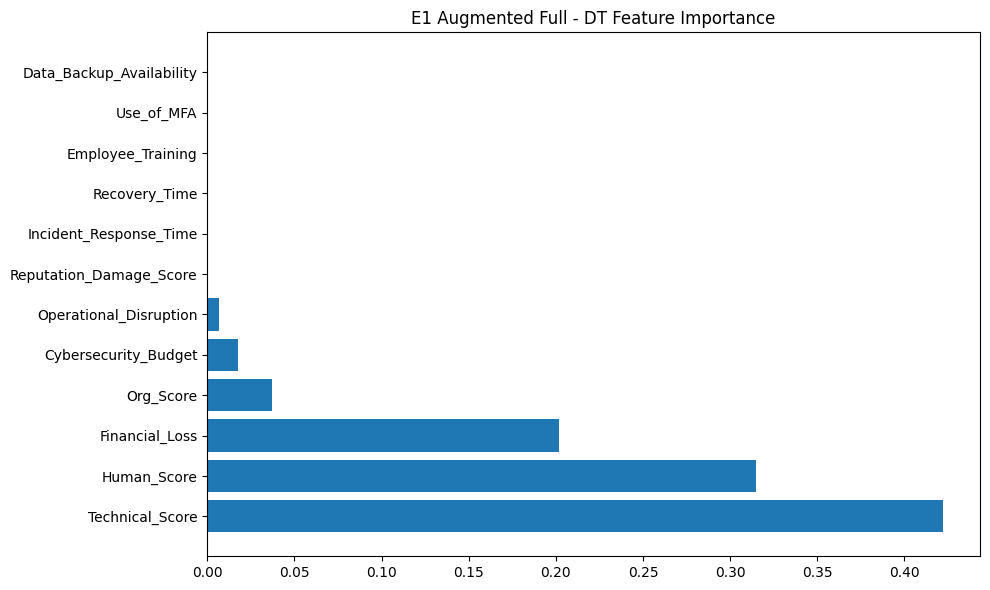

Decision Tree Model Saved Successfully


In [33]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd
import joblib

dt_model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

dt_accuracy = evaluate_model(
    dt_model,
    X_train,
    X_test,
    y_train,
    y_test
)

# Confusion Matrix
dt_pred = dt_model.predict(X_test)

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    dt_pred,
    cmap="Blues"
)

disp.figure_.savefig(
    "../Outputs/Confusion_Matrices/E1_Augmented_Full_DT.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Feature Importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

fig, ax = plt.subplots(figsize=(10,6))

ax.barh(
    importance["Feature"],
    importance["Importance"]
)

ax.set_title(
    "E1 Augmented Full - DT Feature Importance"
)

fig.tight_layout()

fig.savefig(
    "../Outputs/Feature_Importance/E1_Augmented_Full_DT_Feature_Importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show(fig)

joblib.dump(
    dt_model,
    "../Models/decision_tree.pkl"
)

print("Decision Tree Model Saved Successfully")

## 7. Random Forest


Model: RandomForestClassifier
Accuracy: 0.9225
              precision    recall  f1-score   support

        High       0.95      0.94      0.94       544
         Low       0.94      0.94      0.94       528
      Medium       0.87      0.89      0.88       528

    accuracy                           0.92      1600
   macro avg       0.92      0.92      0.92      1600
weighted avg       0.92      0.92      0.92      1600



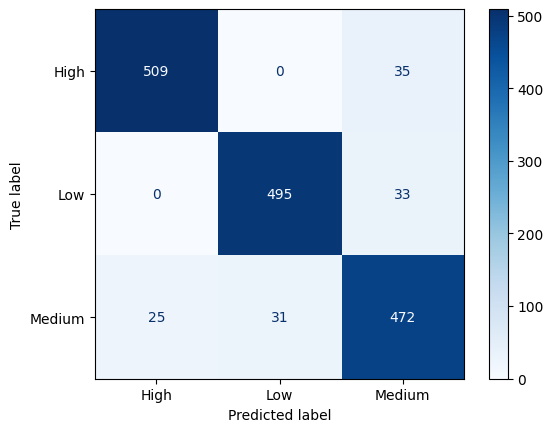

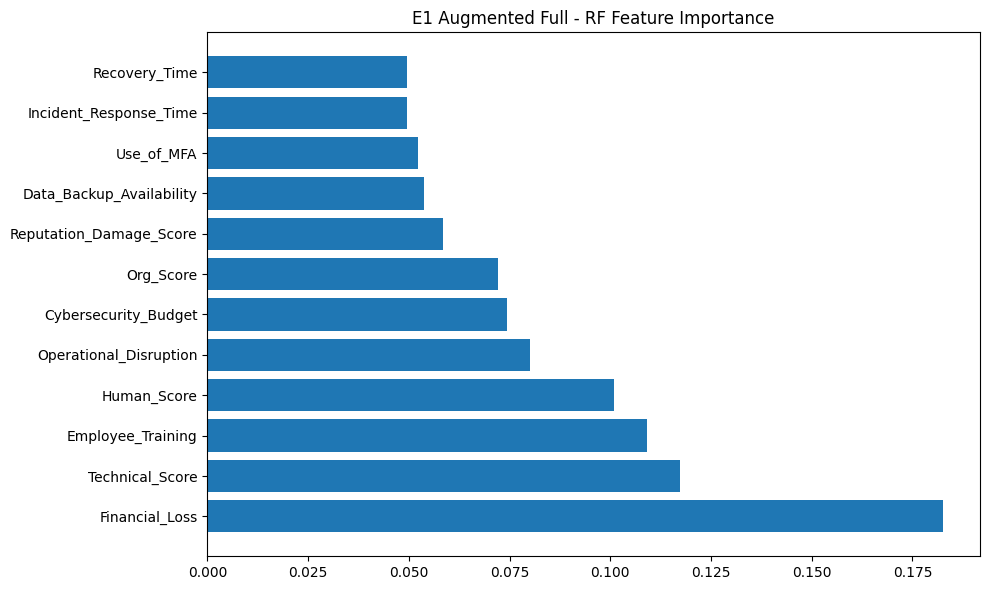

Random Forest Model Saved Successfully


In [34]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd
import joblib

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_accuracy = evaluate_model(
    rf_model,
    X_train,
    X_test,
    y_train,
    y_test
)

# Confusion Matrix
rf_pred = rf_model.predict(X_test)

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred,
    cmap="Blues"
)

disp.figure_.savefig(
    "../Outputs/Confusion_Matrices/E1_Augmented_Full_RF.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Feature Importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

fig, ax = plt.subplots(figsize=(10,6))

ax.barh(
    importance["Feature"],
    importance["Importance"]
)

ax.set_title(
    "E1 Augmented Full - RF Feature Importance"
)

fig.tight_layout()

fig.savefig(
    "../Outputs/Feature_Importance/E1_Augmented_Full_RF_Feature_Importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show(fig)

joblib.dump(
    rf_model,
    "../Models/random_forest.pkl"
)

print("Random Forest Model Saved Successfully")

## 8. XGBoost Model

XGBOOST RESULTS
Accuracy: 0.9219

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.94      0.94       544
           1       0.95      0.93      0.94       528
           2       0.87      0.90      0.88       528

    accuracy                           0.92      1600
   macro avg       0.92      0.92      0.92      1600
weighted avg       0.92      0.92      0.92      1600


Confusion Matrix:
[[509   0  35]
 [  0 493  35]
 [ 28  27 473]]


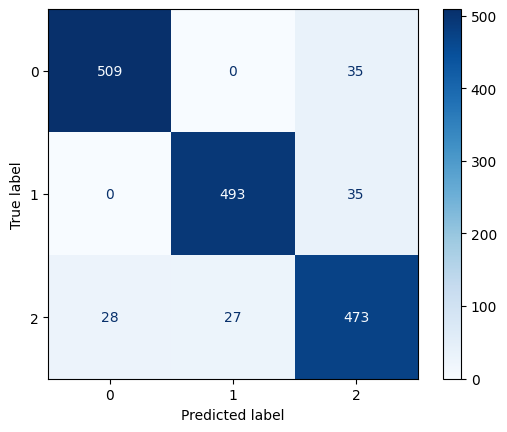


Feature Importance:
                     Feature  Importance
6          Employee_Training    0.294319
9            Technical_Score    0.226815
0             Financial_Loss    0.127599
5       Cybersecurity_Budget    0.102512
2    Reputation_Damage_Score    0.087639
1     Operational_Disruption    0.063741
4              Recovery_Time    0.039045
3     Incident_Response_Time    0.031822
8   Data_Backup_Availability    0.014535
7                 Use_of_MFA    0.011974
10               Human_Score    0.000000
11                 Org_Score    0.000000


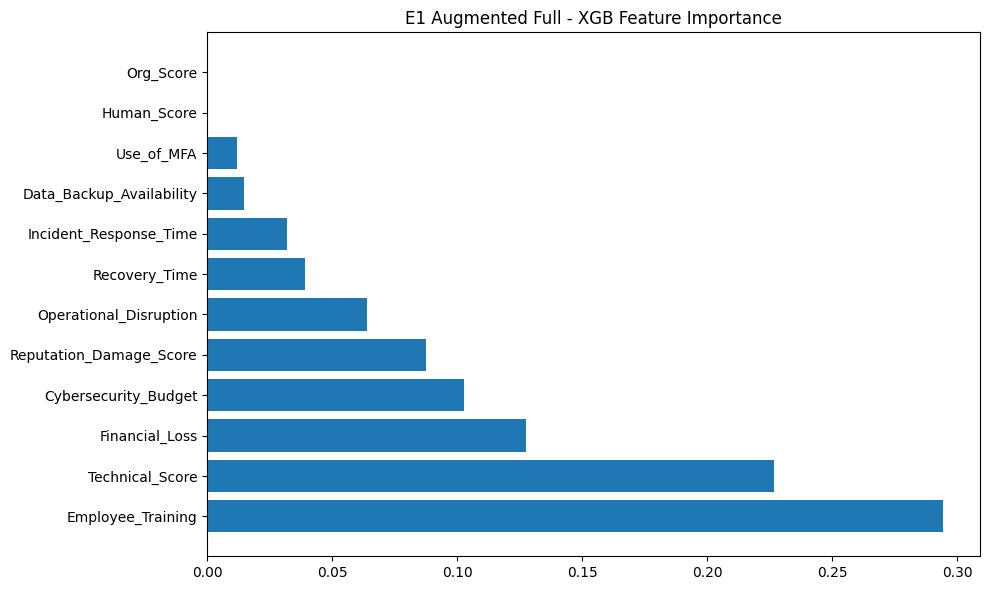

XGBoost Model Saved Successfully


In [35]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

import pandas as pd
import matplotlib.pyplot as plt
import joblib

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(
    df["Risk_Level"]
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric="mlogloss"
)

xgb_model.fit(
    X_train,
    y_train
)

y_pred = xgb_model.predict(
    X_test
)

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("=" * 50)
print("XGBOOST RESULTS")
print("=" * 50)

print(f"Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred
    )
)

# Confusion Matrix Figure
disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

disp.figure_.savefig(
    "../Outputs/Confusion_Matrices/E1_Augmented_Full_XGB.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Feature Importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nFeature Importance:")
print(importance)

fig, ax = plt.subplots(figsize=(10,6))

ax.barh(
    importance["Feature"],
    importance["Importance"]
)

ax.set_title(
    "E1 Augmented Full - XGB Feature Importance"
)

fig.tight_layout()

fig.savefig(
    "../Outputs/Feature_Importance/E1_Augmented_Full_XGB_Feature_Importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show(fig)

joblib.dump(
    xgb_model,
    "../Models/xgboost.pkl"
)

print("XGBoost Model Saved Successfully")

## 9. Export Result To CSV

In [36]:
import pandas as pd

results = pd.DataFrame({
    "Experiment": ["E3_Augmented_Full"],
    "DT": [dt_accuracy * 100],
    "RF": [rf_accuracy * 100],
    "XGB": [accuracy * 100]
})

print(results)

results.to_csv(
    "/Users/prakashpanta/Desktop/Cyber_Security_Risk_Assessment/Outputs/Tables/All_Results.csv",
    mode="a",
    header=False,
    index=False
)

print("E3 Results Saved Successfully")

          Experiment       DT     RF      XGB
0  E3_Augmented_Full  76.4375  92.25  92.1875
E3 Results Saved Successfully
